In [623]:
import torch

In [624]:
# load data fashonMnist
from torchvision import datasets, transforms

train_data = datasets.FashionMNIST(root="dummy_data", download=True, train=True, transform=transforms.ToTensor())

test_data = datasets.FashionMNIST(root="dummy_data", download=True, train=False, transform=transforms.ToTensor())



len(train_data) , len(test_data)

(60000, 10000)

In [625]:
# visulaize the inputs
import matplotlib.pyplot as plt


image_data, label_data  = train_data[1]

class_names = train_data.classes

class_names[label_data]

image_data.shape

torch.Size([1, 28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

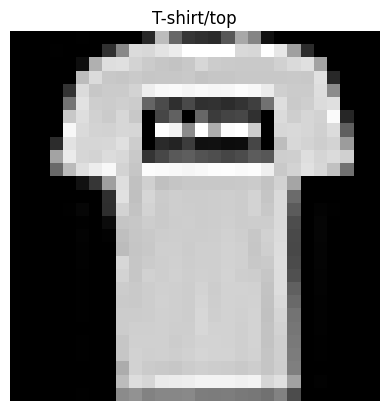

In [626]:
plt.imshow(image_data.permute(1,2,0), cmap="gray")
plt.title(class_names[label_data])
plt.axis("off")

In [627]:
# dataloader - to put data into batchs

len(train_data)
batch_size = 32

len(train_data) / 32

1875.0

In [628]:
from torch.utils.data import DataLoader

train_data_loader = DataLoader(dataset=train_data,  batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(dataset=test_data, batch_size=batch_size)

len(train_data_loader) ,len(test_data_loader)

(1875, 313)

In [629]:
# python generator
batch_image, batch_label = next(iter(train_data_loader))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

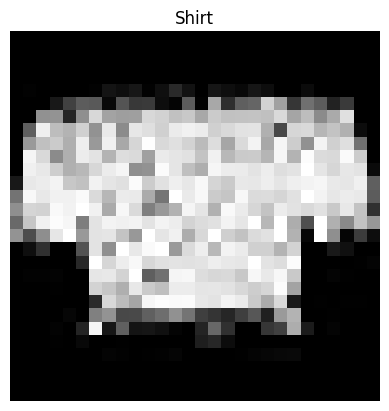

In [630]:
plt.imshow(batch_image[31].permute(1,2,0), cmap="gray")
plt.title(class_names[batch_label[31]])
plt.axis("off")

In [631]:
from torch import nn
class BaseLine(nn.Module):
    def __init__(self):
         super().__init__()
         self.layers = nn.Sequential(
             nn.Flatten(),
             nn.Linear(in_features=784, out_features=10),
             nn.ReLU(), 
             nn.Linear(in_features=10, out_features=10),
             nn.ReLU(),

             
         )
    def forward(self, x):
        return self.layers(x)
         

In [632]:
model = BaseLine()

model

BaseLine(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

In [633]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


In [634]:
#loop
from helper import accuracy_fn
EPOCHS = 1
for epoch in range(EPOCHS):
    print("EPOCHS : ", epoch)
    model.train()
    train_loss = 0 # 1800
    for batch, (X,y) in enumerate(train_data_loader):
        train_logit  = model(X)
        loss = loss_fn(train_logit, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if batch % 400 == 0:
            print(f"Look at sample {batch * len(X)}/ {len(train_data_loader) * len(X)}")
    train_loss /= len(train_data_loader)
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X,y in test_data_loader:
            test_logit = model(X)
            loss = loss_fn(test_logit, y)
            test_loss += loss
            test_pred = test_logit.argmax(1)
            test_acc += accuracy_fn(y, test_pred)
        test_loss /= len(test_data_loader)
        test_acc /=  len(test_data_loader)

    
    print(f"Train Loss : {train_loss} | Test loss : {test_loss} | Test acc : {test_acc}")
       
    
            
            
    
            

EPOCHS :  0
Look at sample 0/ 60000
Look at sample 12800/ 60000
Look at sample 25600/ 60000
Look at sample 38400/ 60000
Look at sample 51200/ 60000
Train Loss : 0.6748844112555186 | Test loss : 0.5533994436264038 | Test acc : 80.59105431309904


In [635]:




Xi, yi = (next(iter(test_data_loader)))
Xi = Xi[18]
yi = yi[18]



In [636]:
# evaluate the model
import random
model.eval()
with torch.inference_mode():
    logits = model(Xi)
    preds = logits.argmax(1)
    print(preds)

tensor([8])


In [637]:
yi

tensor(8)

In [638]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_results = eval_model(model=model, data_loader=test_data_loader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)

model_results

{'model_name': 'BaseLine',
 'model_loss': 0.5533994436264038,
 'model_acc': 80.59105431309904}

In [639]:
eval_model(model=model, data_loader=test_data_loader, loss_fn=loss_fn, accuracy_fn=accuracy_fn)

{'model_name': 'BaseLine',
 'model_loss': 0.5533994436264038,
 'model_acc': 80.59105431309904}

In [640]:
len(test_data_loader)

313

In [641]:

Xi, yi = (next(iter(test_data_loader)))
Xi = Xi[21]
yi = yi[21]

tensor([7])


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

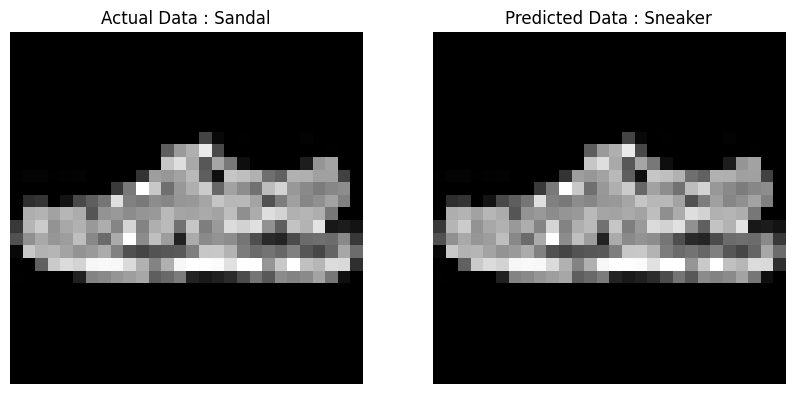

In [642]:
#visulaize
import matplotlib.pyplot as plt

plt.figure(figsize=(10,16))

plt.subplot(1,2,1)
plt.imshow(Xi.permute(1,2,0), cmap="gray")
plt.title(f"Actual Data : {class_names[yi]}")
plt.axis(("off"))

# evaluate the model
import random
model.eval()
with torch.inference_mode():
    logits = model(Xi)
    preds = logits.argmax(1)
    print(preds)

plt.subplot(1,2,2)
plt.imshow(Xi.permute(1,2,0), cmap="gray")
plt.title(f"Predicted Data : {class_names[preds]}")
plt.axis(("off"))


In [643]:
# device agonstic code
device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    device = "cuda" # gpu nvidai
elif torch.backends.mps.is_available():
    device = "mps" # apple
else:
    device = "cpu"
    


device

'mps'

In [644]:
from torch import nn

class TopLine(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
           
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=10, out_channels=10, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=10 * 7 * 7, # 250
                      out_features=10)
        )
        
        
    def forward(self, x):
        # print("Input shape of X : ",  x.shape)
        x = self.block_1(x)
        # print("Input shape of after block 1 : ",  x.shape)
        x = self.block_2(x)
        # print("Input shape of after block 2 : ",  x.shape)
        x = self.classifier(x)
        # print("Input shape of after classifier: ",  x.shape)
        return x

In [645]:
topline_model = TopLine()

topline_model

TopLine(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [646]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1)) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [ ]:
epochhs = 20
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(topline_model.parameters(), lr=0.1)


for epoch in  range(epochhs):
    print("EPOCHS : ", epoch)
    train_step(model=topline_model, optimizer=optimizer, loss_fn=loss_fn, accuracy_fn=accuracy_fn, data_loader=train_data_loader, device=device)
    test_step(model=topline_model, accuracy_fn=accuracy_fn, loss_fn=loss_fn, device=device, data_loader=test_data_loader)
    print("*" * 100)


EPOCHS :  0
Train loss: 0.61936 | Train accuracy: 77.56%
Test loss: 0.43107 | Test accuracy: 84.05%

****************************************************************************************************
EPOCHS :  1
Train loss: 0.36365 | Train accuracy: 87.01%
Test loss: 0.35280 | Test accuracy: 87.33%

****************************************************************************************************
EPOCHS :  2
Train loss: 0.33137 | Train accuracy: 88.08%
Test loss: 0.33352 | Test accuracy: 87.87%

****************************************************************************************************
EPOCHS :  3
Train loss: 0.31204 | Train accuracy: 88.81%
Test loss: 0.32398 | Test accuracy: 88.32%

****************************************************************************************************
EPOCHS :  4
Train loss: 0.29879 | Train accuracy: 89.14%
Test loss: 0.32862 | Test accuracy: 87.95%

*******************************************************************************************

In [649]:
# [32, 10, 5, 5])
# RuntimeError: linear(): input and weight.T shapes cannot be multiplied (32x250 and 10x10)

test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: dummy_data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [651]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: dummy_data
    Split: Test
    StandardTransform
Transform: ToTensor()

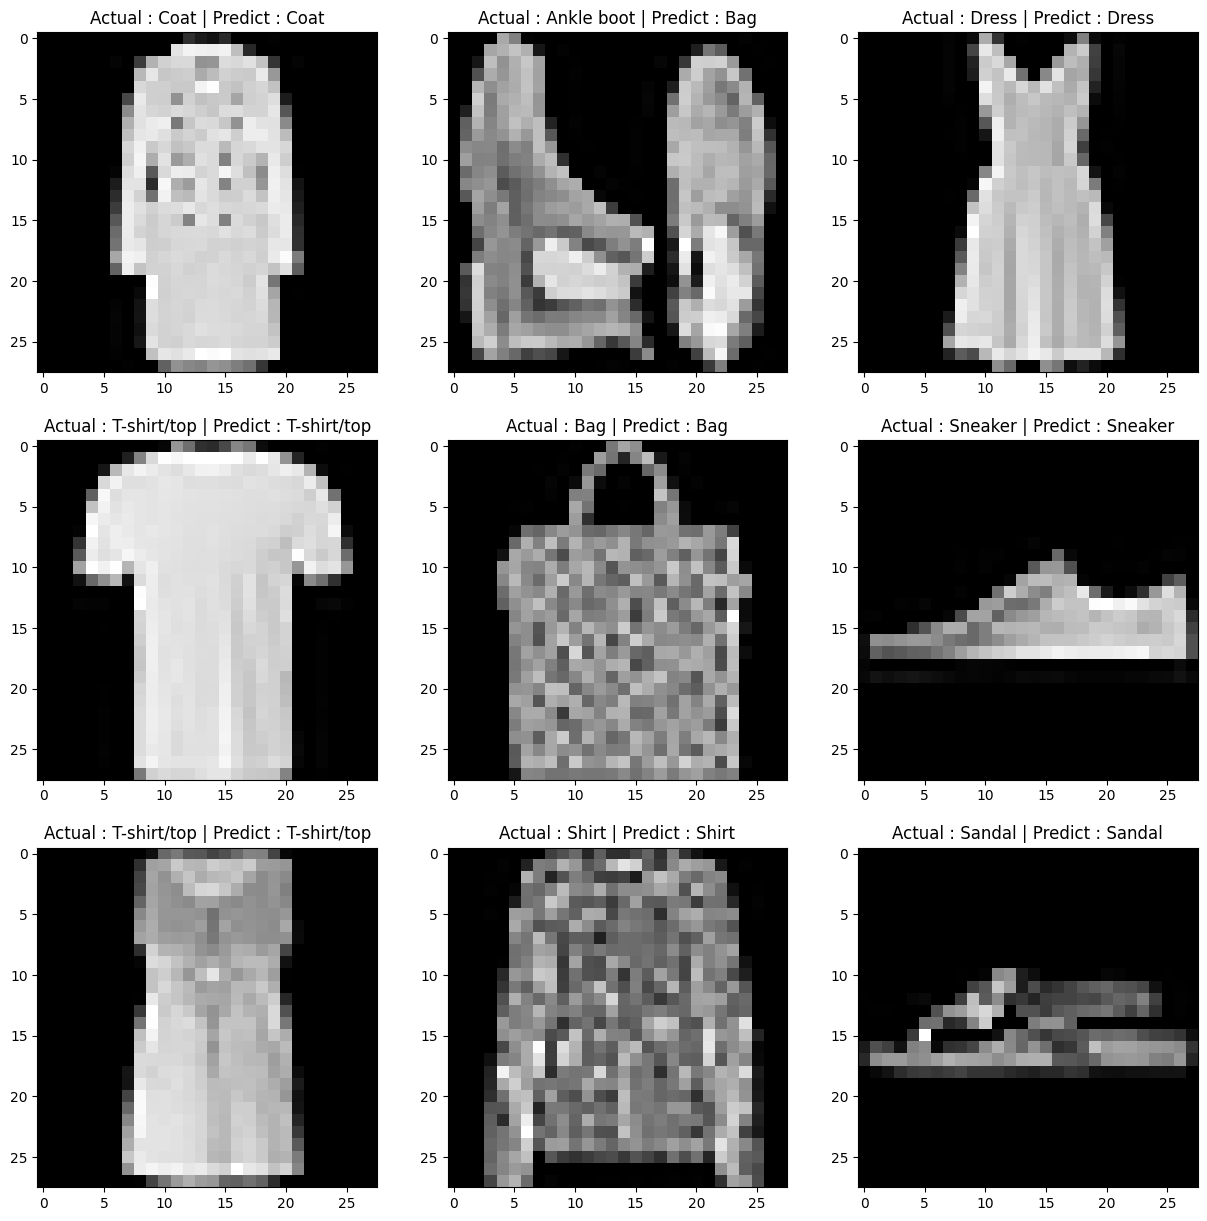

In [695]:
import random

Xid = random.sample(list(test_data), k=9)
plt.figure(figsize=(15,15))

for i, (imgs,val) in enumerate(Xid):
    plt.subplot(3,3, i+1)
    plt.imshow(imgs.permute(1,2,0), cmap="gray")
    topline_model.eval()
    with torch.inference_mode():
        imgs = imgs.to(device)
        logits = topline_model(imgs.unsqueeze(1)).argmax(1)
        plt.title(f"Actual : {class_names[val]} | Predict : {class_names[logits.item()]}")


<Figure size 1500x1500 with 0 Axes>

<Figure size 1500x1500 with 0 Axes>